<a href="https://colab.research.google.com/github/JagdishMane/numpy-pytorch-tensorflow/blob/main/Predicting_Stock_Prices_Using_RNN_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RNN with LSTM


In [34]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn

## Data Preparation

In [35]:
df = pd.read_csv('./M3-AAPL.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2019-05-28,44.730000,45.147499,44.477501,44.557499,43.002316,111792800
1,2019-05-29,44.105000,44.837502,44.000000,44.345001,42.797237,113924800
2,2019-05-30,44.487499,44.807499,44.167500,44.575001,43.019211,84873600
3,2019-05-31,44.057499,44.497501,43.747501,43.767502,42.239895,108174400
4,2019-06-03,43.900002,44.480000,42.567501,43.325001,41.812828,161584400


In [36]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1259.000000,1259.000000,1259.000000,1259.000000,1259.000000,1.259000e+03
mean,133.653819,135.147178,132.262275,133.769406,132.106947,9.655618e+07
std,42.756938,43.062934,42.436917,42.756727,43.073091,5.190515e+07
min,43.860001,44.480000,42.567501,43.325001,41.812828,2.404830e+07
25%,112.485000,113.725003,110.000000,112.064999,109.641697,6.313855e+07
50%,143.800003,146.220001,142.539993,144.289993,142.543701,8.347440e+07
75%,169.345001,171.014999,168.154999,169.300003,168.303947,1.131188e+08
max,198.020004,199.619995,197.000000,198.110001,197.589523,4.265100e+08


In [37]:
### Check Missing values.
missing_values = df.isnull().sum()
display(missing_values)

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1259 non-null   object 
 1   Open       1259 non-null   float64
 2   High       1259 non-null   float64
 3   Low        1259 non-null   float64
 4   Close      1259 non-null   float64
 5   Adj Close  1259 non-null   float64
 6   Volume     1259 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 69.0+ KB


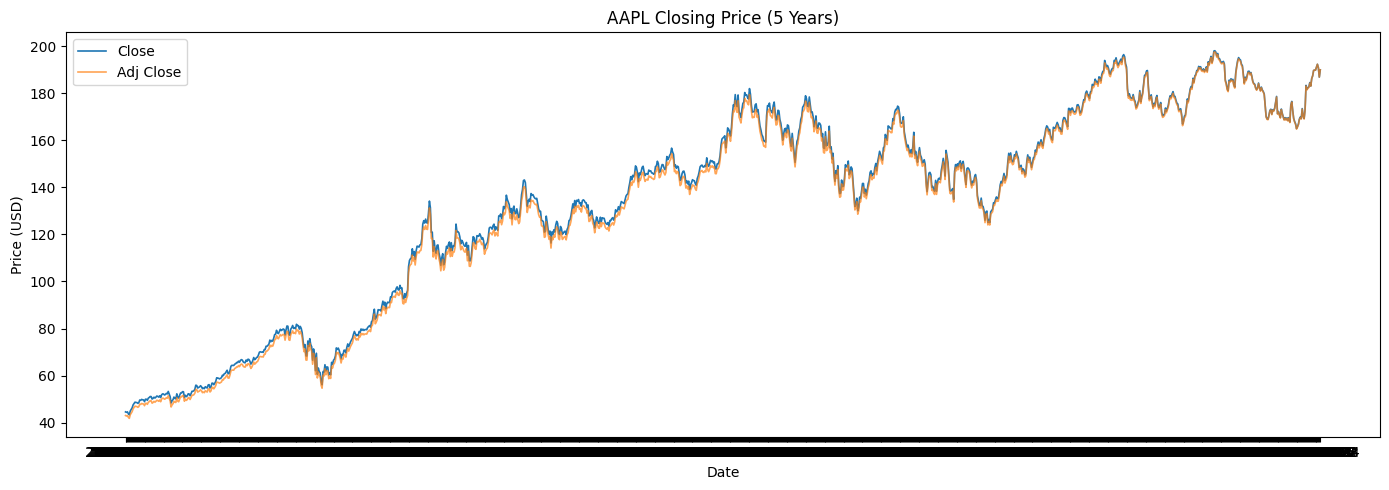

In [39]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["Date"], df["Close"], label="Close", linewidth=1.2)
ax.plot(df["Date"], df["Adj Close"], label="Adj Close", linewidth=1.2, alpha=0.7)
ax.set_title("AAPL Closing Price (5 Years)")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.tight_layout()
plt.show()

## Feature Selection

We will predict the **Close** price using a sliding windows of past closing prices.

In [40]:
TARGET = "Close"       ### Target column for prediction
seq_lenght = 60          ### Past 60 days used to predict the next day Close price - Lookback window


prices = df[[TARGET]].values.astype("float32")
train_size = int(len(prices) * 0.8)
test_size = len(prices) - train_size
train_prices = prices[:train_size,:]
test_prices = prices[train_size:len(prices),:]
print(f"Train raw data size: {len(train_prices)}")
print(f"Test raw data size: {len(test_prices)}")

Train raw data size: 1007
Test raw data size: 252


In [41]:
### Normalize the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
train_data = scaler.fit_transform(train_prices)
test_data = scaler.transform(test_prices)

In [42]:
### Create the training data
window_size = seq_length
X_train, y_train = [], []
for i in range(window_size, len(train_data)):
    X_train.append(train_data[i-window_size:i, 0])
    y_train.append(train_data[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

### Respahe the training data
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [43]:
### Create the testing data
X_test, y_test = [], []
for i in range(window_size, len(test_data)):
    X_test.append(test_data[i-window_size:i, 0])
    y_test.append(test_data[i, 0])
X_test, y_test = np.array(X_test), np.array(y_test)

### Reshape the testing dat
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

## RNN LSTM Model

In [50]:
import tensorflow as tf

### Build the LSTM Model
model = tf.keras.Sequential([
  tf.keras.layers.LSTM(units=64, return_sequences=True, input_shape=(window_size, 1)),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.LSTM(units=32, return_sequences=True),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(32, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(1)
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

### Train the Model
model.fit(X_train, y_train, epochs=300, batch_size=64)



Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.2583 - mae: 0.4351
Epoch 2/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1487 - mae: 0.3232
Epoch 3/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.1180 - mae: 0.2902
Epoch 4/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.1018 - mae: 0.2738
Epoch 5/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0945 - mae: 0.2600
Epoch 6/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0909 - mae: 0.2555
Epoch 7/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0888 - mae: 0.2541
Epoch 8/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0872 - mae: 0.2520
Epoch 9/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0860 - mae: 0.2480
Epoch 10/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0848 - mae: 0.2476
Epoch 11/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0844 - mae: 0.2454
Epoch 12/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0836 - mae: 0.2465
Epoch 13/300
16/16 ━━━━━━━━━━━━━━━━━━

## Prediction and Evaluation

In [51]:
# Evaluate the model on the test data
mse = model.evaluate(X_test, y_test)
print(f"MSE: {mse}")

# Make prediction on the test data
predictions = model.predict(X_test)

# Reshape predictions to 2D by taking the last timestep's output
predictions = predictions[:, -1, :]

# Denormalize the predictions and actual values.
predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 33126.1055 - mae: 181.8036  
MSE: [33126.10546875, 181.8036346435547]
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step


## PLOT

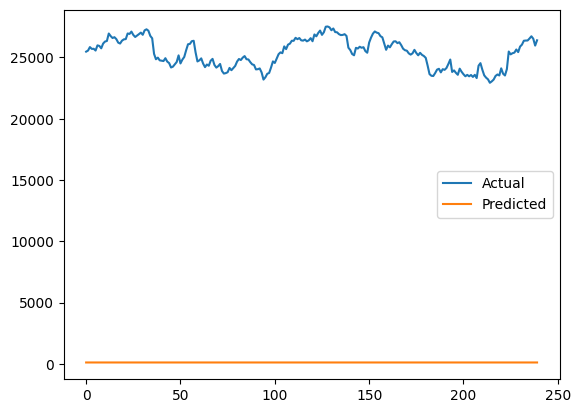

In [52]:
# Plot the predictions and actual values
import matplotlib.pyplot as plt
plt.plot(y_test, label='Actual')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.show()

## Forcast for N days
